In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pywt
import warnings
from tqdm import tqdm
from dotenv import load_dotenv

from rfml_uav.drone_rf.consts import BUI, BUI_dict
from rfml_uav.drone_rf.utils import get_segment_count

plt.rc("font", family="Times New Roman")
warnings.filterwarnings("ignore")
load_dotenv()

True

In [2]:
# Path of raw RF data
load_path = os.path.join(os.getenv("DATA_PATH"), "chunked")
save_path = os.path.join(os.getenv("DATA_PATH"), "Wavelets")
os.makedirs(save_path, exist_ok=True)

wavelet = 'dmey'
level = 6

In [ ]:
# Function to compute RMS
def compute_rms(signal):
    return np.sqrt(np.mean(np.square(signal)))


# Function to compute STD
def compute_std(signal):
    return np.std(signal)


# Function to extract features using DWT
def wavelet_packet_decomposition(signal, wavelet, level=6):
    wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric')
    nodes = wp.get_level(level, 'freq')
    feature_vector = []

    for node in nodes:
        rms = compute_rms(node.data)
        std = compute_std(node.data)
        feature_vector.extend([rms, std])

    return feature_vector


def get_wavelet_data(bui: str):
    data = []
    N = get_segment_count(bui)

    for n in tqdm(range(N)):
        x_chunks = np.load(os.path.join(load_path, f"{bui}L_{n}.npz"))['arr_0']
        y_chunks = np.load(os.path.join(load_path, f"{bui}H_{n}.npz"))['arr_0']

        for i in range(len(x_chunks)):
            x_features = wavelet_packet_decomposition(x_chunks[i], wavelet=wavelet, level=level)
            y_features = wavelet_packet_decomposition(y_chunks[i], wavelet=wavelet, level=level)
            data.append(x_features + y_features)

    return np.array(data)

In [ ]:
data = []
bui = '00000'
n = 0

x_chunks = np.load(os.path.join(load_path, f"{bui}L_{n}.npz"))['arr_0']
y_chunks = np.load(os.path.join(load_path, f"{bui}H_{n}.npz"))['arr_0']

for i in range(len(x_chunks)):
    x_features = wavelet_packet_decomposition(x_chunks[i], wavelet=wavelet, level=level)
    y_features = wavelet_packet_decomposition(y_chunks[i], wavelet=wavelet, level=level)
    data.append(x_features + y_features)

np.array(data).shape

In [ ]:
for bui in BUI:
    data = get_wavelet_data(bui)
    np.savetxt(os.path.join(save_path, f'{bui}.csv'), data, delimiter=',')

## Wavelet Packet Decomposition Example

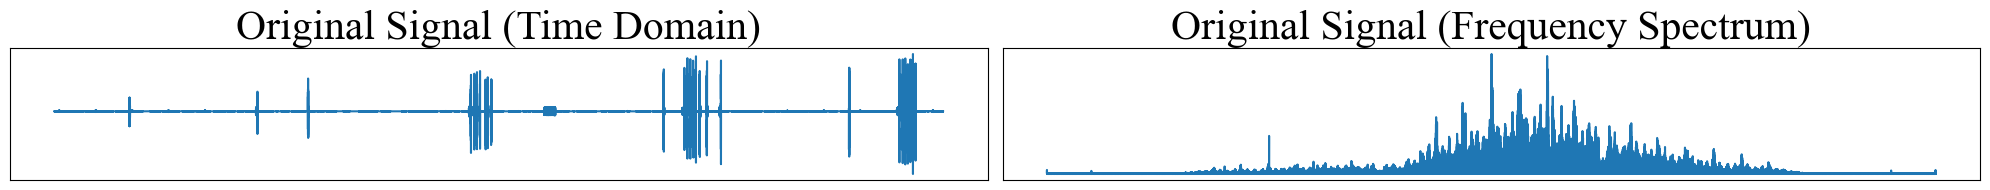

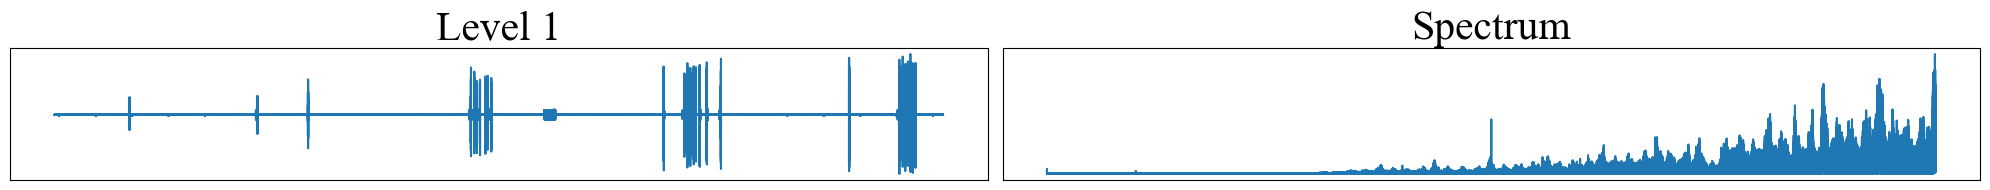

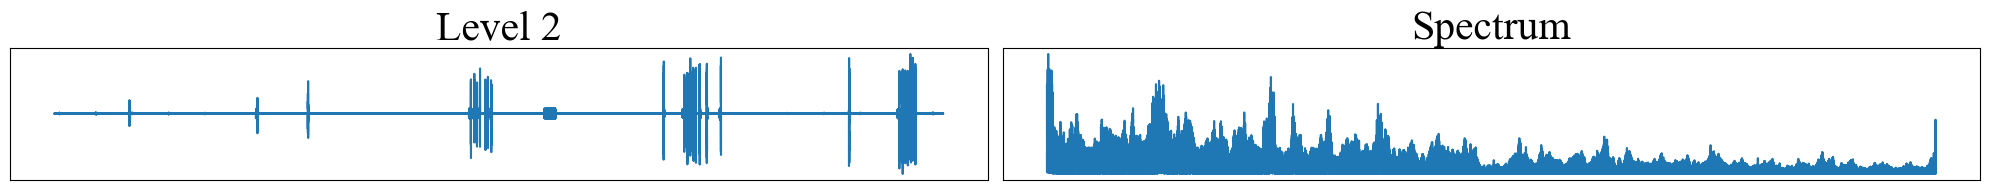

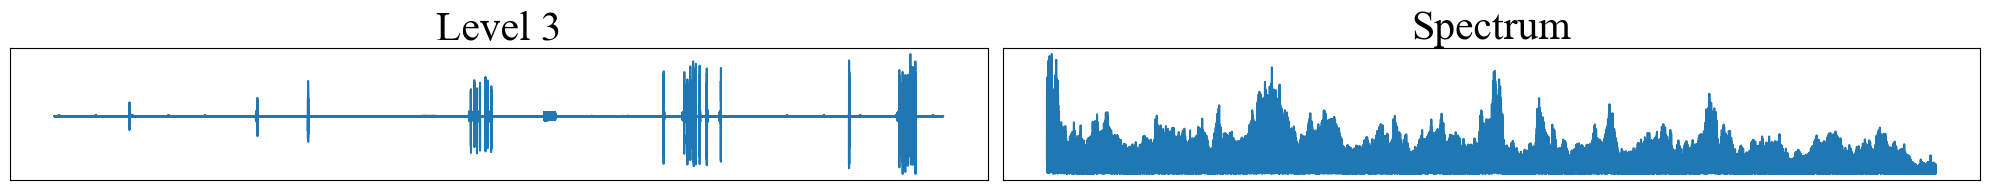

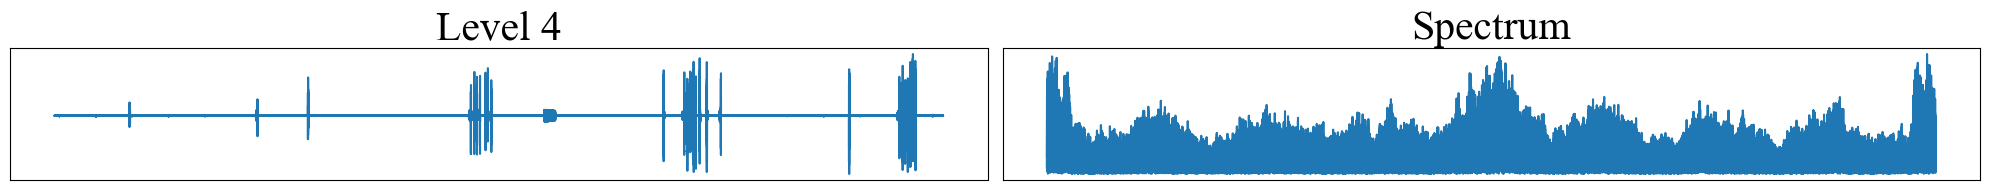

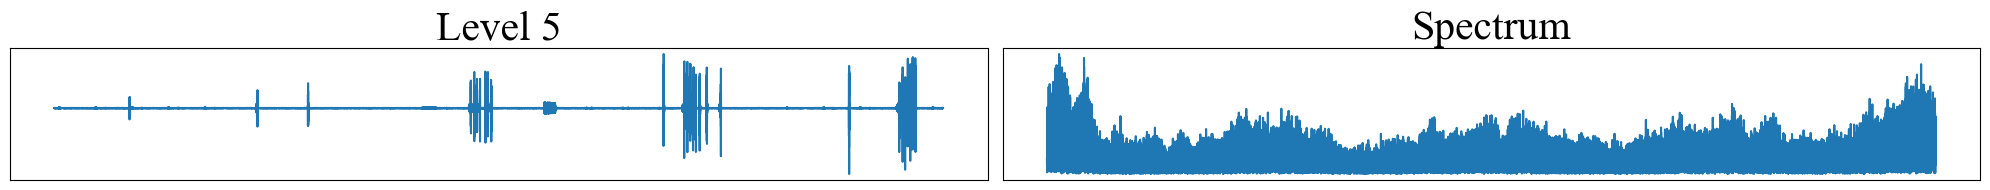

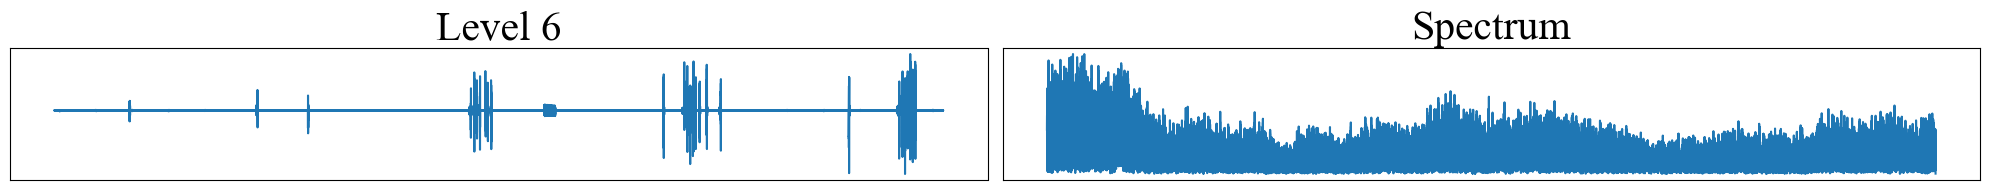

In [22]:
load_path = os.path.join(os.getenv("DATA_PATH"), "raw")
drone_type = "AR"
mode = 1
bui = BUI_dict[drone_type][mode]
n = 1

signal = np.loadtxt(os.path.join(load_path, f"{bui}L_{n}.csv"), delimiter=',')
# Frequency-domain plot using FFT
fs = 80  # Sampling frequency in Hz (adjust as needed)
freqs = np.fft.rfftfreq(len(signal), 1/fs)  # Frequency axis
fft_values = np.abs(np.fft.rfft(signal))  # Compute FFT

# Perform Wavelet Packet Decomposition
wp = pywt.WaveletPacket(data=signal, wavelet=wavelet, mode='symmetric', maxlevel=level)

#Plotting
plt.figure(figsize=(20, 2))
# Time domain plot
plt.subplot(1, 2, 1)
plt.plot(signal)
plt.title("Original Signal (Time Domain)", fontsize = 30)
plt.xticks([]) 
plt.yticks([]) 
# Frequency domain plot
plt.subplot(1, 2, 2)
plt.plot(fft_values)
plt.title("Original Signal (Frequency Spectrum)", fontsize = 30)
plt.xticks([]) 
plt.yticks([]) 
plt.tight_layout()
plt.show()

# Get all nodes at each level
levels = wp.maxlevel
for i in range(levels):
    nodes = [node.path for node in wp.get_level(i + 1, order="natural")]
    reconstructed = sum(wp[node].reconstruct() for node in nodes)

    # Frequency-domain plot using FFT
    freqs = np.fft.rfftfreq(len(reconstructed), 1/fs)  # Frequency axis
    fft_values = np.abs(np.fft.rfft(reconstructed))  # Compute FFT

    #Plotting
    plt.figure(figsize=(20, 2))
    # Time domain plot
    plt.subplot(1, 2, 1)
    plt.plot(reconstructed)
    plt.title(f'Level {i+1}', fontsize = 30)
    plt.xticks([]) 
    plt.yticks([]) 
    # Frequency domain plot
    plt.subplot(1, 2, 2)
    plt.plot(fft_values)
    plt.title('Spectrum', fontsize = 30)
    plt.xticks([]) 
    plt.yticks([]) 
    plt.tight_layout()
    plt.show()
